In this cell below, I am importing the libraries required for the project. I use requests to send API calls, base64 to decode the image returned by the API, and IPython display tools to show the generated image directly inside the notebook.

In [22]:
import requests
import base64
from IPython.display import Image, display


In this cell below, I am providing the API key and the endpoint URL needed to connect with Stability AI Stable Diffusion. These values allow the notebook to authenticate with the service and send image generation or image editing requests.

In [ ]:

# Use env var instead of hardcoding key
api_key = "Your API Key"
url = "https://api.stability.ai/v2beta/stable-image/generate/sd3"


In this cell below, I am setting up the request headers required by the Stability AI API. The authorization header sends the API key securely with the request, and the accept header tells the API to return the response in JSON format.

In [24]:

headers = {
    "Authorization": f"Bearer {api_key}",
    "Accept": "application/json"
}


In the cell below, I am defining the input data for the first image generation request. The prompt describes the frog image I want to create, while the other parameters such as model, seed, configuration scale, output format, and aspect ratio control the quality and style of the generated image.

In [25]:

data = {
    "prompt": "A hyper-realistic close up of a green tree frog sitting on a lotus leaf eating bug, macro photography, 8k resolution, highly detailed",
    "model": "sd3.5-large",
    "seed": "1024",
    "cfg_scale": "7",
    "output_format": "png",
    "aspect_ratio": "1:1"
}


In the cell below, I am sending the request to Stability AI to generate the original image. After receiving the response, I check whether the request was successful, decode the returned image data, and display the image directly in the notebook.

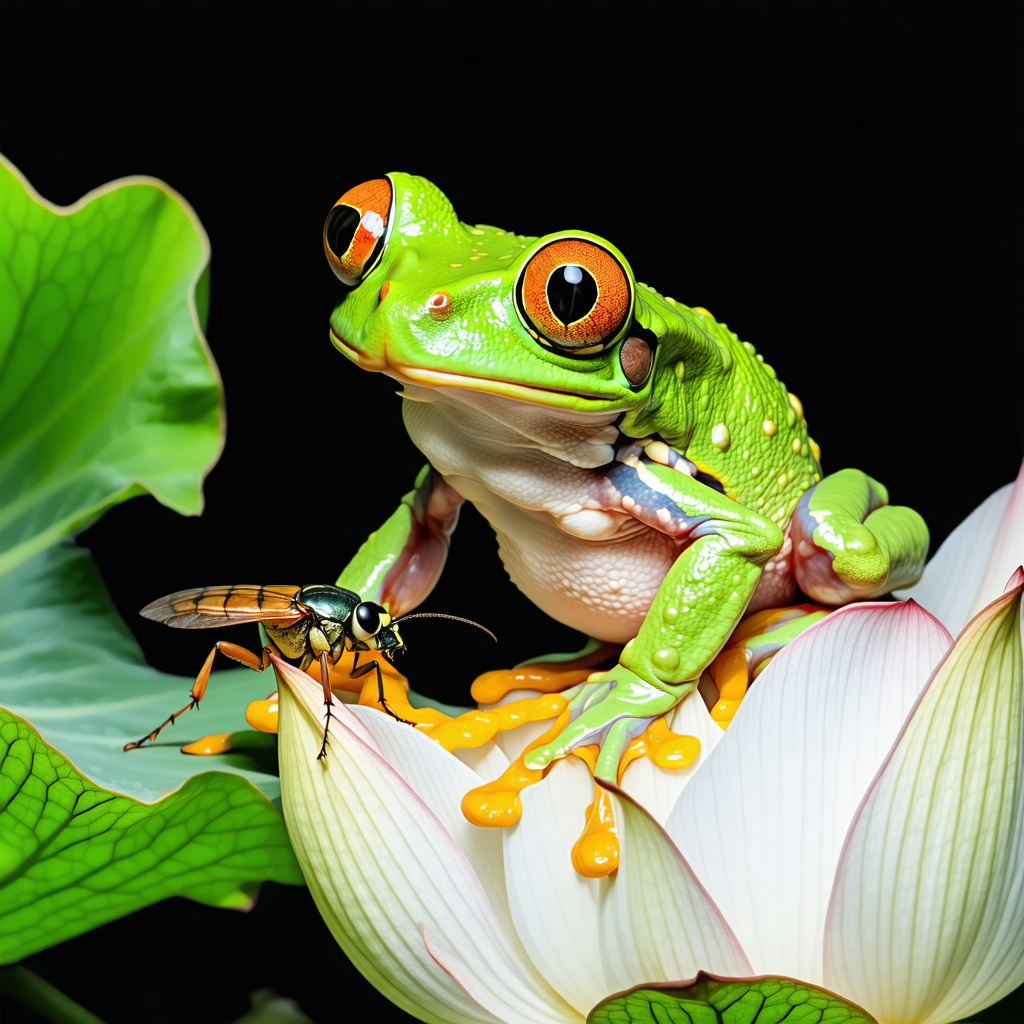

In [26]:

# files is required so requests sends multipart/form-data
response = requests.post(url, headers=headers, data=data, files={"none": ("", "")})

if response.status_code != 200:
    raise Exception(f"Non-200 response: {response.text}")

payload = response.json()

if "image" in payload:
    image_bytes = base64.b64decode(payload["image"])
    display(Image(data=image_bytes))
elif "artifacts" in payload:
    
    for image in payload["artifacts"]:
        image_bytes = base64.b64decode(image["base64"])
        display(Image(data=image_bytes))
else:
    raise Exception(f"Unexpected response format: {payload}")

In this cell, I am preparing a second request to edit the previously generated image. Here, I provide a new prompt to modify the frog, set the mode to image-to-image, and adjust parameters such as strength, model, seed, configuration scale, and output format. I also specify the image file that will be used as the base image for editing.

In [27]:
data = {
    "prompt": "Remove the bug, keep the frog, lotus leaf and macro photo style",
    "mode": "image-to-image",
    "strength": 0.75,
    "model": "sd3.5-large",
    "seed": 1024,
    "cfg_scale": 8,
    "output_format": "png"
}

files = {
    "image": open("generated_frog_0.png", "rb")
}


In the next block I am sending the image editing request to Stability AI. Once the API returns the updated result, I verify the response, decode the returned image, and display the edited version inside the notebook.

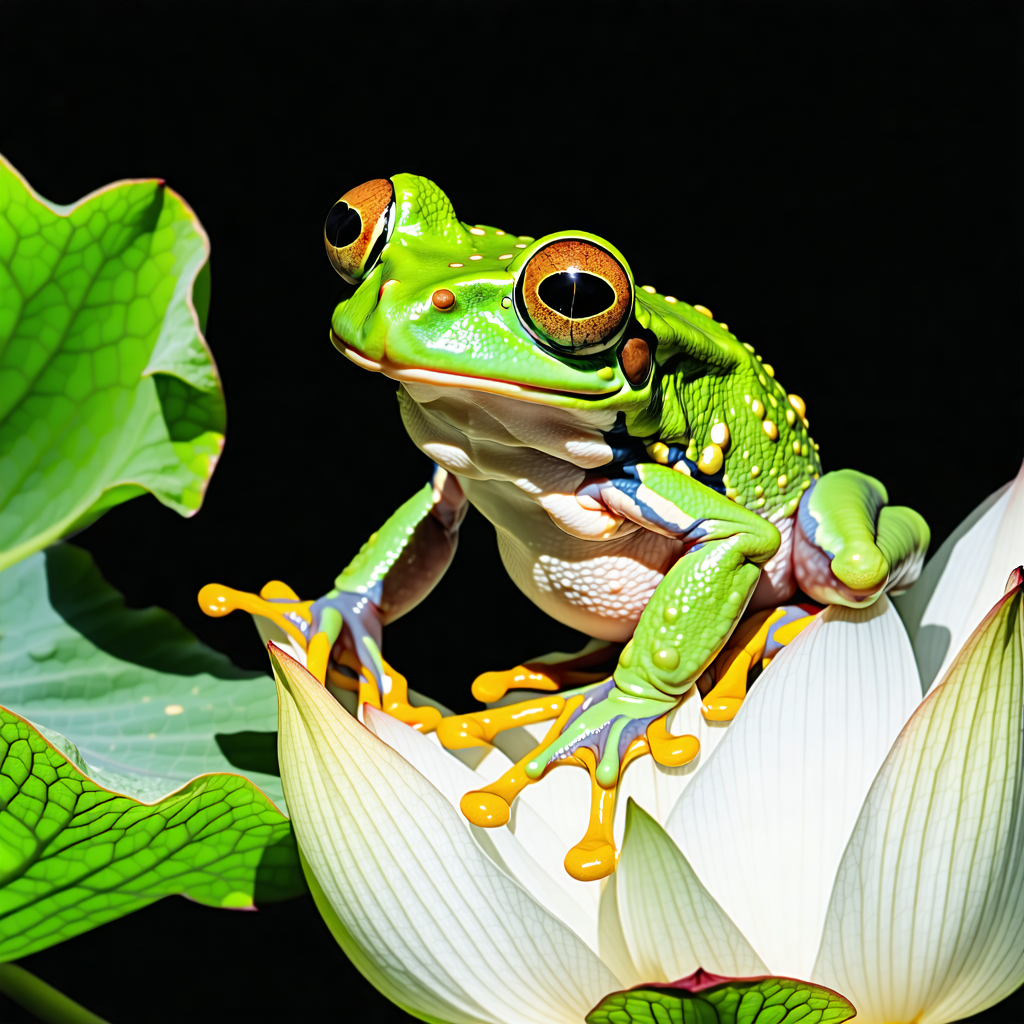

In [28]:
response = requests.post(url, headers=headers, data=data, files=files)


if response.status_code != 200:
    raise Exception(f"Non-200 response: {response.text}")

payload = response.json()

if "image" in payload:
    image_bytes = base64.b64decode(payload["image"])
    display(Image(data=image_bytes))
elif "artifacts" in payload:
    
    for image in payload["artifacts"]:
        image_bytes = base64.b64decode(image["base64"])
        display(Image(data=image_bytes))
else:
    raise Exception(f"Unexpected response format: {payload}")

**COnclusion**     

The results from the Stability AI API were impressive in terms of image quality and prompt adherence. The initial image generation produced a highly detailed and realistic frog, closely matching the descriptive prompt. When I used the image to image editing feature to modify the original image, for example, to remove the bug or change the frog’s color; the API was able to make targeted changes while preserving the overall composition and style of the original.
From a usability perspective, the API is straightforward for anyone familiar with Python and REST APIs. The issue is if you want to edit the image you generated you have to make sure the same image is being transmitted back. Overall it was easy